In [19]:
import math
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt

from PIL import Image
from statsbombpy import sb

from mplsoccer import VerticalPitch


import math

from scipy.spatial import ConvexHull

In [2]:
df_raw = sb.events(match_id= 3869685).sort_values(by= ['index'])

In [3]:
df = df_raw.copy(deep= 1)

In [4]:
# Team IDs
ARGENTINA_TEAM_ID = 779
FRANCE_TEAM_ID = 771

# Team Colors
ARGENTINA_COLOR = "#74ACDF"   # Argentina sky blue
FRANCE_COLOR = "#ED2939"      # France navy blue

# Alternative accent colors
ARGENTINA_SECONDARY = "#FFFFFF"
FRANCE_SECONDARY = "#ED2939"  # French red

In [5]:
PITCH_COLOR = "#22312B"
LINE_COLOR = "#EFE9DC"

In [6]:
df.period

0       1
1       1
2       1
3       1
12      1
       ..
4287    5
4244    5
4288    5
4403    5
4404    5
Name: period, Length: 4407, dtype: int64

In [7]:
df = df[df.period < 5]

In [8]:
team1 = df[df.team == 'Argentina']
team2 = df[df.team == 'France']

In [26]:
def create_shotmap(team, ax, team_name="Shot Map"):

    pitch = VerticalPitch(
        pitch_type='statsbomb',
        half=True,
        pitch_color="#14213D",
        line_color="#F8F9FA",
        linewidth=2
    )

    pitch.draw(ax=ax)

    shots = team[team['type'] == 'Shot'].copy()

    shots = shots[
        [
            'player',
            'location',
            'shot_outcome',
            'shot_statsbomb_xg'
        ]
    ]

    shots[['x', 'y']] = shots['location'].apply(
        lambda x: pd.Series(x[:2]) if isinstance(x, list)
        else pd.Series([None, None])
    )

    shots = shots.dropna(subset=['x', 'y'])

    for _, shot in shots.iterrows():

        outcome = shot['shot_outcome']
        xg = shot['shot_statsbomb_xg']

        if outcome == 'Goal':
            color = '#00FF88'

        elif outcome in ['Blocked']:
            color = '#FF595E'

        elif outcome in ['Post', 'Saved To Post']:
            color = '#00B4D8'

        elif outcome in ['Off T', 'Wayward']:
            color = '#FFD166'

        else:
            color = '#F8F9FA'

        pitch.scatter(
            shot['x'],
            shot['y'],
            s=max(80, xg * 3000),
            color=color,
            edgecolors='black',
            linewidth=1.2,
            alpha=0.85,
            ax=ax
        )

    total_shots = len(shots)
    goals = (shots['shot_outcome'] == 'Goal').sum()
    total_xg = shots['shot_statsbomb_xg'].sum()

    ax.text(
        0.03,
        0.95,
        f"Shots: {total_shots}\nGoals: {goals}\nxG: {total_xg:.2f}",
        transform=ax.transAxes,
        fontsize=12,
        color='white',
        verticalalignment='top',
        bbox=dict(
            facecolor='#000000',
            alpha=0.7,
            boxstyle='round'
        )
    )

    ax.set_title(
        team_name,
        fontsize=20,
        color='white',
        fontweight='bold',
        pad=15
    )

In [20]:
def create_passnetwork(team, ax, team_name="Pass Network"):

    # ---------------------------
    # PREPROCESSING
    # ---------------------------
    team = team.copy()

    team[['x', 'y']] = team['location'].apply(
        lambda x: pd.Series(x) if isinstance(x, list) else pd.Series([np.nan, np.nan])
    )

    tactics = team.loc[
        team['tactics'].notna(),
        ['tactics', 'team']
    ]

    all_jersey_numbers = []

    for row in tactics.to_dict(orient='records'):

        lineup_df = pd.DataFrame([
            {
                'player_id': player['player']['id'],
                'jersey_number': player['jersey_number']
            }
            for player in row['tactics']['lineup']
        ])

        all_jersey_numbers.append(lineup_df)

    jersey_numbers = (
        pd.concat(all_jersey_numbers)
        .drop_duplicates()
    )

    # ---------------------------
    # SORT EVENTS
    # ---------------------------
    team['newsecond'] = (
        team['minute'] * 60 +
        team['second']
    )

    team = team.sort_values('newsecond')

    # ---------------------------
    # PASSER / RECIPIENT
    # ---------------------------
    team['passer'] = team['player_id']
    team['recipient'] = team['passer'].shift(-1)

    # ---------------------------
    # PASSES ONLY
    # ---------------------------
    passes_df = team.loc[
        team['type'] == 'Pass'
    ].copy()

    passes_df['pass_outcome'] = (
        passes_df['pass_outcome']
        .fillna('Successful')
    )

    completions = passes_df.loc[
        passes_df['pass_outcome'] == 'Successful'
    ].copy()

    # ---------------------------
    # FIRST SUBSTITUTION
    # ---------------------------
    sub_df = team.loc[
        team['type'] == 'Substitution'
    ]

    if len(sub_df) > 0:
        first_sub = sub_df['newsecond'].min()

        if first_sub <= 45 * 60:
            first_sub = 45 * 60

        completions = completions.loc[
            completions['newsecond'] < first_sub
        ]

    # ---------------------------
    # AVERAGE LOCATIONS
    # ---------------------------
    average_locs_and_count = (
        completions
        .groupby('passer')
        .agg({
            'x': ['mean'],
            'y': ['mean', 'count']
        })
    )

    average_locs_and_count.columns = [
        'x',
        'y',
        'count'
    ]

    # ---------------------------
    # PASSES BETWEEN PLAYERS
    # ---------------------------
    passes_between = (
        completions
        .groupby(['passer', 'recipient'])
        .id.count()
        .reset_index()
    )

    passes_between.rename(
        columns={'id': 'pass_count'},
        inplace=True
    )

    passes_between = passes_between.merge(
        average_locs_and_count,
        left_on='passer',
        right_index=True
    )

    passes_between = passes_between.merge(
        average_locs_and_count,
        left_on='recipient',
        right_index=True,
        suffixes=['', '_end']
    )

    # ---------------------------
    # FILTER WEAK CONNECTIONS
    # ---------------------------
    passes_between = passes_between.loc[
        passes_between['pass_count'] >= 4
    ]

    # ---------------------------
    # VISUAL SCALING
    # ---------------------------
    MAX_NODE_SIZE = 2500

    average_locs_and_count['marker_size'] = (
        average_locs_and_count['count']
        / average_locs_and_count['count'].max()
        * MAX_NODE_SIZE
    )

    max_passes = passes_between['pass_count'].max()

    passes_between['line_width'] = (
        passes_between['pass_count']
        / max_passes
        * 10
    )

    passes_between['alpha'] = (
        passes_between['pass_count']
        / max_passes
    )

    # ---------------------------
    # PITCH
    # ---------------------------
    pitch = VerticalPitch(
        pitch_type='statsbomb',
        pitch_color='#0B132B',
        line_color='white'
    )

    pitch.draw(ax=ax)

    # ---------------------------
    # TEAM SHAPE
    # ---------------------------
    if len(average_locs_and_count) >= 3:

        points = average_locs_and_count[['x', 'y']].values

        hull = ConvexHull(points)

        hull_points = points[hull.vertices]

        ax.fill(
            hull_points[:, 1],
            hull_points[:, 0],
            alpha=0.08,
            color='white',
            zorder=0
        )

    # ---------------------------
    # PASS LINES
    # ---------------------------
    for _, row in passes_between.iterrows():

        ax.plot(
            [row['y'], row['y_end']],
            [row['x'], row['x_end']],
            color='white',
            linewidth=row['line_width'],
            alpha=max(0.2, row['alpha']),
            zorder=1
        )

    # ---------------------------
    # MOST INVOLVED PLAYER
    # ---------------------------
    top_player = (
        average_locs_and_count['count']
        .idxmax()
    )

    node_colors = [
        '#FFD700' if idx == top_player else '#F8F9FA'
        for idx in average_locs_and_count.index
    ]

    # ---------------------------
    # PLAYER NODES
    # ---------------------------
    pitch.scatter(
        average_locs_and_count.x,
        average_locs_and_count.y,
        s=average_locs_and_count.marker_size,
        color=node_colors,
        edgecolors='black',
        linewidth=2,
        ax=ax,
        zorder=3
    )

    # ---------------------------
    # JERSEY NUMBERS
    # ---------------------------
    for idx, row in average_locs_and_count.iterrows():

        try:
            jersey = jersey_numbers.loc[
                jersey_numbers['player_id'] == idx,
                'jersey_number'
            ].values[0]

            pitch.annotate(
                jersey,
                xy=(row.x, row.y),
                color='black',
                ha='center',
                va='center',
                size=11,
                fontweight='bold',
                ax=ax,
                zorder=4
            )

        except:
            pass

    # ---------------------------
    # TITLE
    # ---------------------------
    ax.set_title(
        team_name,
        fontsize=20,
        color='white',
        fontweight='bold',
        pad=20
    )

    ax.set_facecolor('#0B132B')

In [11]:
def create_table(team1, team2):
    # Drop rows where the pass_outcome is Unknown
    team1 = team1[team1['pass_outcome'] != 'Unknown']
    team2 = team2[team2['pass_outcome'] != 'Unknown']
    
    # Create a table with the data
    # We first need to calculate the statistics for each team
    # we will calcualte the following stats:
    # - goals
    # - xG
    # - shots
    # - shots on target
    # - passes
    # - pass completion %
    
    # Create a dictionary to store the stats
    stats = {
        'goals': {'team1': len(team1[team1['type'] == 'Goal']), 'team2': len(team2[team2['type'] == 'Goal'])},
        'xG': {'team1': round(team1['shot_statsbomb_xg'].sum(), 2), 'team2': round(team2['shot_statsbomb_xg'].sum(), 2)},
        'shots': {'team1': len(team1[team1['type'] == 'Shot']), 'team2': len(team2[team2['type'] == 'Shot'])},
        'shots_on_target': {
            'team1': len(team1[(team1['type'] == 'Shot') & (team1['shot_end_location'].str.len() > 2) & (team1['shot_outcome'] != 'Off T')]), 
            'team2': len(team2[(team2['type'] == 'Shot') & (team2['shot_end_location'].str.len() > 2) & (team2['shot_outcome'] != 'Off T')])
        },
        'passes': {'team1': len(team1[team1['type'] == 'Pass']), 'team2': len(team2[team2['type'] == 'Pass'])},
        'pass_completion': {
            'team1': round(len(team1[(team1['type'] == 'Pass') & (team1['pass_outcome'].isna())]) / len(team1[team1['type'] == 'Pass']) * 100, 2) ,
            'team2': round(len(team2[(team2['type'] == 'Pass') & (team2['pass_outcome'].isna())]) / len(team2[team2['type'] == 'Pass']) * 100, 2)
        }
    }
    
    # store as a dataframe
    stats_df = pd.DataFrame(stats).T

    column_labels = ['', '', '']
    table_vals = [
        [str(stats_df['team1']['xG']), 'xG', str(stats_df['team2']['xG'])],
        [str(stats_df['team1']['shots']), 'Shots', str(stats_df['team2']['shots'])],
        [str(stats_df['team1']['shots_on_target']), 'Shots on Target', str(stats_df['team2']['shots_on_target'])],
        [str(stats_df['team1']['passes']), 'Passes', str(stats_df['team2']['passes'])],
        [str(stats_df['team1']['pass_completion']), 'Pass Completion %', str(stats_df['team2']['pass_completion'])]
    ]
    
    return column_labels, table_vals

In [12]:
def create_xg_flow_chart(df, ax):
    # We'll use the original df instead of the team1 and team2 dataframes
    
    # Filter the columns to only shots
    df = df[df['type'] == 'Shot']
    
    # Sort the values so they are in order of time
    df = df.sort_values(by="index")
    
    # Calculate the cumulative xG for each team
    df['cumulative_xG'] = df.groupby('team_id')['shot_statsbomb_xg'].cumsum()
    
    # Plot the xG for each team by half
    # We want to make it so the lines both start at 0
    for team in df['team_id'].unique():
        
        team_df = df[df['team_id'] == team]
        
        # add a 0 xG row at the start of the match
        team_df = pd.concat([pd.DataFrame({
            'team_id': team, 'minute': 0, 'shot_statsbomb_xg': 0, 'shot_outcome': None, 'cumulative_xG': 0, 'period': 1
        }, index=[0]), team_df])
        
        ax.plot(
            team_df['minute'], 
            team_df['cumulative_xG'], 
            label=team, 
            drawstyle='steps-post',
            c=ARGENTINA_COLOR if team == ARGENTINA_TEAM_ID else FRANCE_COLOR
        )   
            
    
    # We Can add a scatter plot to show the goals
    for team in df['team_id'].unique():
        team_df = df[(df['team_id'] == team) & (df['shot_outcome'] == 'Goal')].to_dict(orient='records')
        for x in team_df:
            ax.scatter(
                x['minute'], 
                x['cumulative_xG'], 
                c='white',
                edgecolor=ARGENTINA_COLOR if team == ARGENTINA_TEAM_ID else FRANCE_COLOR,
                s=100,
                # We want the goals to be on top of the lines
                zorder=5
            )
            
            # add a label to the goals for the player who scored
            ax.text(
                x['minute'], 
                x['cumulative_xG'] - .07, 
                x['player'], 
                ha='center', 
                va='center', 
                fontfamily='monospace', 
                fontsize=8,
                zorder=10
            )
            
    # Let's label the x axis with first and second half
    ax.set_xticks([0, 45, 90, 120])
    ax.set_xticklabels(['0\'', '45\'', '90\'', '120\''])
    
    # Let's get rid of the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

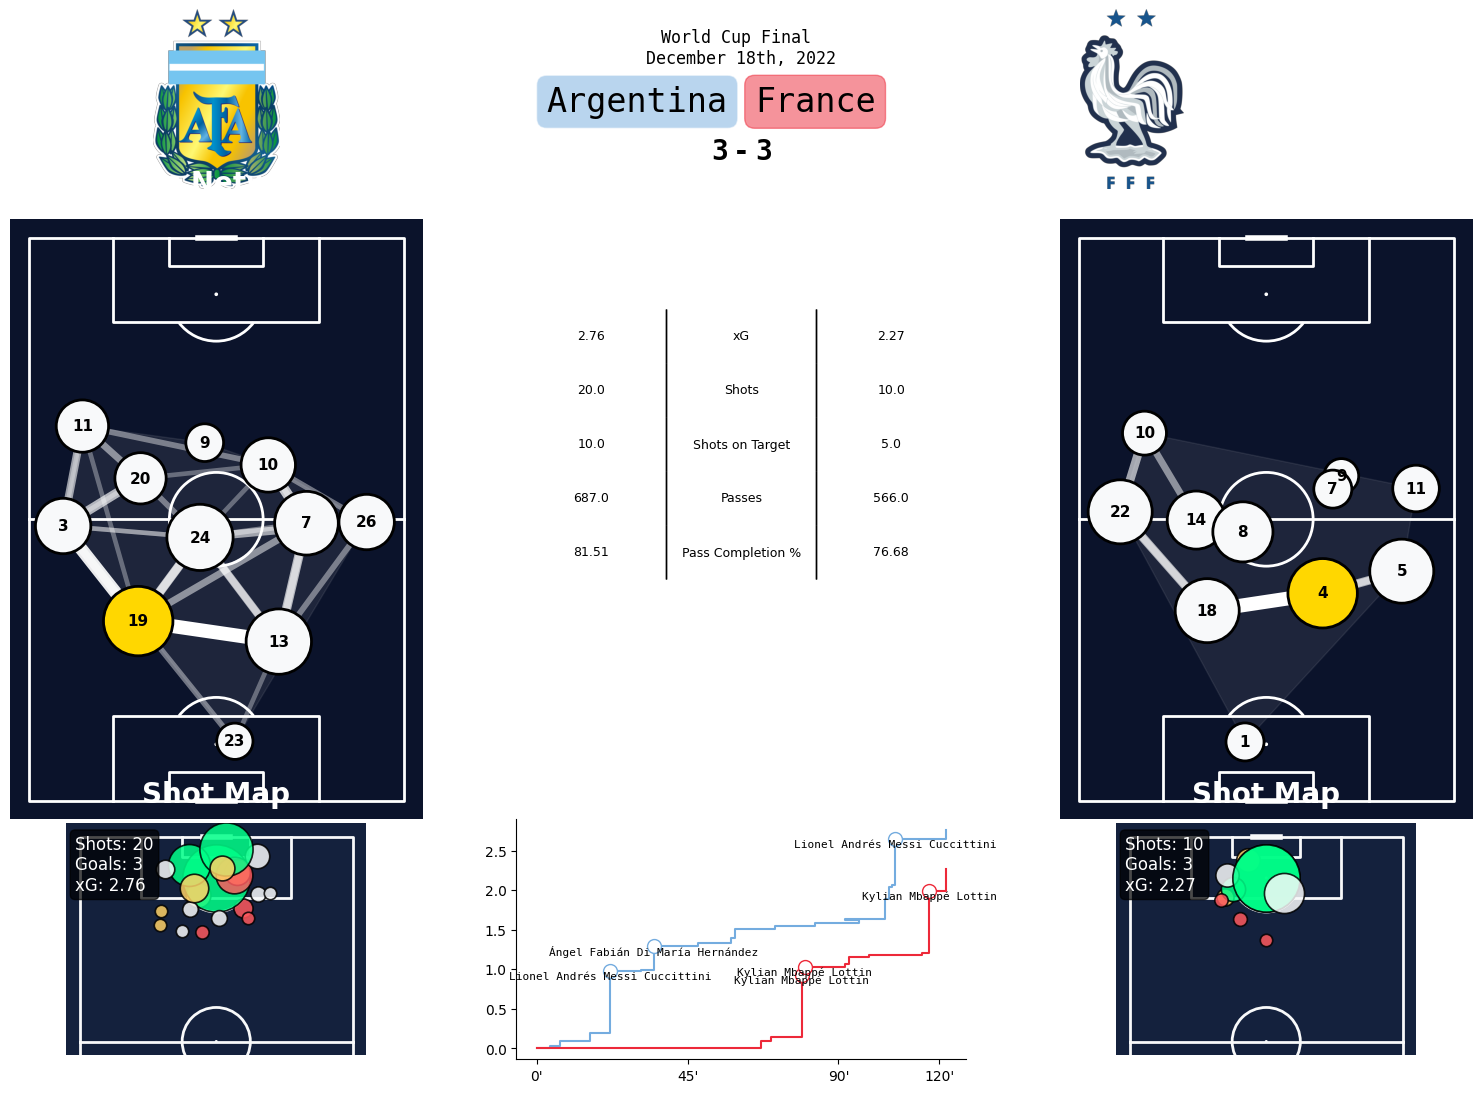

In [28]:
fig = plt.figure(figsize= (15, 12))

ax1 = fig.add_axes([.225, .775, .15, .15])

team1_img = Image.open('../team-logos/argentina_logo.png')
ax1.imshow(team1_img)
ax1.axis('off')

ax2 = fig.add_axes([.5, .8, .3, .1])
ax2.text(.5, .8, 'World Cup Final \nDecember 18th, 2022', fontsize = 12, ha= 'center', fontdict= {'family' : 'monospace'})

team1_txt = ax2.text(.47, .4, 'Argentina', fontsize = 24, ha = 'right', fontdict= {'family': 'monospace'})
team1_txt.set_bbox(dict(facecolor= ARGENTINA_COLOR, alpha= .5, edgecolor = ARGENTINA_SECONDARY, boxstyle = 'round'))

team2_txt = ax2.text(.53, .4, 'France', fontsize = 24, ha = 'left', fontdict= {'family': 'monospace'})
team2_txt.set_bbox(dict(facecolor= FRANCE_SECONDARY, alpha= .5, edgecolor = FRANCE_SECONDARY, boxstyle = 'round'))

ax2.text(.47, 0, '3',
         fontsize=20,
         ha='right',
         fontdict={'family': 'monospace', 'weight': 'bold'})

ax2.text(.50, 0, '-',
         fontsize=20,
         ha='center',
         fontdict={'family': 'monospace', 'weight': 'bold'})

ax2.text(.53, 0, '3',
         fontsize=20,
         ha='left',
         fontdict={'family': 'monospace', 'weight': 'bold'})

ax2.axis('off')


ax3 = fig.add_axes([.85, .775, .12, .15])
team2_img = Image.open('../team-logos/france_logo.png')
ax3.imshow(team2_img)
ax3.axis('off')

ax4 = fig.add_axes([.15, .25, .3, .5])
create_passnetwork(team1, ax4)

ax5 = fig.add_axes([.5, .2, .3, .5])
# create a table with data. The middle column will be the statistic with the left and right columns being the stats for each team
column_labels, table_vals = create_table(team1, team2)

table = ax5.table(
    cellText=table_vals, 
    cellLoc='center', 
    edges='vertical',
    bbox=[0, .5, 1, .45],
)

table.set_fontsize(14)

for (i, j), cell in table.get_celld().items():
    if j == 0:
        table.get_celld()[(i, j)].visible_edges = 'R'
    elif j == 2:
        table.get_celld()[(i, j)].visible_edges = 'L'
    else:
        table.get_celld()[(i, j)].visible_edges = 'LR'

ax5.axis('off')


ax6 = fig.add_axes([0.85, 0.25, 0.3, 0.5])
create_passnetwork(team2, ax6)
# ax6.axis('off')

ax7 = fig.add_axes([0.2, 0.05, 0.2, 0.2])
create_shotmap(team1, ax7)
# ax7.axis('off')

ax8 = fig.add_axes([0.5, 0.05, 0.3, 0.2])
create_xg_flow_chart(df, ax8)
# ax8.axis('off')

ax9 = fig.add_axes([0.9, 0.05, 0.2, 0.2])
create_shotmap(team2, ax9)
# ax9.axis('off')